<div align="center">
  <img src="https://raw.githubusercontent.com/devicons/devicon/master/icons/python/python-original.svg" width="80"/>
</div>

<h1 align="center">Redes Neurais Artificiais, Deep Learning e Algoritmos Genéticos</h1>

<h3 align="center">PhD. Julles Mitoura</h3>

<div align="center">
  <img src="https://img.shields.io/badge/Python-3776AB?style=for-the-badge&logo=python&logoColor=white"/>
  <img src="https://img.shields.io/badge/Jupyter-F37626?style=for-the-badge&logo=jupyter&logoColor=white"/>
  <img src="https://img.shields.io/badge/PyTorch-EE4C2C?style=for-the-badge&logo=pytorch&logoColor=white"/>
</div>

---

## Instalação das dependências

| Biblioteca | Uso |
|------------|-----|
| `numpy` | Geração e manipulação dos datasets |
| `matplotlib` | Visualizações |
| `scikit-learn` | Normalização (`StandardScaler`) e métricas |
| `torch` | Tensores, RNN e otimizadores |

In [1]:
#%pip install numpy matplotlib scikit-learn torch --quiet

## Aula 04: Redes Neurais Recorrentes (RNN)

A FNN da Aula 03 trata cada exemplo de forma **independente** — não há memória entre uma entrada e a próxima. Para dados sequenciais (séries temporais, texto, sinais), a ordem importa: o que veio antes influencia o que vem depois.

As **Redes Neurais Recorrentes (RNNs)** foram criadas exatamente para isso. Nesta aula, construiremos a intuição de como a recorrência funciona, treinaremos modelos práticos com `torch.nn.RNN` e compreenderemos por que RNNs simples têm limitações — preparando o terreno para a LSTM da Aula 05.

### Roteiro

| Seção | Conteúdo |
|-------|----------|
| **1** | Motivação — o que FNNs não conseguem fazer |
| **2** | Arquitetura RNN — estado oculto, desdobramento no tempo, BPTT |
| **3** | Bibliotecas e configuração |
| **4** | Caso 1: Previsão de série temporal (regressão) |
| **5** | Caso 2: Classificação de sequências |
| **6** | Comparativo e próximos passos |

---

## 1. Motivação — Limitações das FNNs para Sequências

Uma FNN recebe um vetor fixo $(x_1, x_2, \ldots, x_n)$ e produz uma saída. Cada exemplo é tratado de forma **completamente independente** — não existe noção de tempo ou ordem.

Para dados sequenciais isso é um problema fundamental:

| Tarefa | Por que a FNN falha |
|--------|---------------------|
| Previsão de série temporal | Os valores $x_{t-1}, x_{t-2}, \ldots$ influenciam $x_t$, mas a FNN não carrega essa informação |
| Classificação de texto | A mesma palavra tem significado diferente dependendo do contexto anterior |
| Reconhecimento de fala | O fonema corrente depende dos anteriores |

### A solução: manter estado

Precisamos de um modelo que **lembre do passado** enquanto processa o presente:

$$h_t = f(x_t,\, h_{t-1})$$

onde $h_t$ é o **estado oculto** no passo $t$ — uma memória comprimida de tudo que foi visto até agora.

---

## 2. Arquitetura RNN

### 2.1 A equação de recorrência

A RNN simples (também chamada de *Vanilla RNN* ou *Elman RNN*) computa o estado oculto em cada passo de tempo como:

$$h_t = \tanh(W_h \cdot h_{t-1} + W_x \cdot x_t + b)$$

onde:
- $x_t \in \mathbb{R}^{d}$ — vetor de entrada no passo $t$
- $h_t \in \mathbb{R}^{H}$ — estado oculto (*hidden state*)
- $W_x \in \mathbb{R}^{H \times d}$ — pesos de entrada
- $W_h \in \mathbb{R}^{H \times H}$ — pesos recorrentes
- $b \in \mathbb{R}^{H}$ — bias

O mesmo conjunto de pesos $(W_x, W_h, b)$ é **compartilhado** em todos os passos de tempo — a rede aprende uma função de transição de estado genérica.

### 2.2 Desdobramento no tempo (*Unrolling*)

Podemos "desenrolar" a RNN ao longo do tempo e enxergá-la como uma rede profunda com camadas compartilhadas:

```
x_1 → [RNN] → h_1
x_2 → [RNN] → h_2   (usa h_1)
x_3 → [RNN] → h_3   (usa h_2)
...
x_T → [RNN] → h_T   (usa h_{T-1}) → saída
```

A saída final $h_T$ carrega a informação acumulada de toda a sequência.

### 2.3 Backpropagation Through Time (BPTT)

O treinamento propaga o gradiente para trás **através dos passos de tempo** — equivalente ao backprop numa rede profunda. O gradiente no passo $t$ depende de todos os passos seguintes:

$$\frac{\partial L}{\partial h_t} = \frac{\partial L}{\partial h_T} \prod_{k=t}^{T-1} \frac{\partial h_{k+1}}{\partial h_k}$$

### 2.4 O problema do gradiente que desvanece

Cada passo multiplica o gradiente por $\frac{\partial h_{k+1}}{\partial h_k} = \text{diag}(\tanh') \cdot W_h$. Para sequências longas:

- Se os valores singulares de $W_h$ forem $< 1$: o gradiente **desvanece exponencialmente** → a rede não aprende dependências de longo prazo
- Se os valores singulares forem $> 1$: o gradiente **explode** → treino instável

Este é o motivo pelo qual a **LSTM** (Aula 05) foi criada: ela resolve o problema do gradiente que desvanece com um mecanismo de gates que protege o fluxo de informação.

### 2.5 FNN vs RNN

| Aspecto | FNN (Aula 03) | RNN (Aula 04) |
|---------|--------------|---------------|
| **Entrada** | Vetor fixo $(batch, features)$ | Sequência $(batch, seq\_len, features)$ |
| **Memória** | Nenhuma | Estado oculto $h_t$ entre passos |
| **Pesos** | Diferentes por camada | Compartilhados no tempo |
| **Gradiente** | Backprop padrão | BPTT — pode desaparecer |
| **PyTorch** | `nn.Linear` | `nn.RNN` |

---

## 3. Bibliotecas

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}")

## 3. Caso 1 — Previsão de Série Temporal (Regressão)

**Objetivo:** prever o próximo valor de uma série temporal sintética com múltiplas frequências a partir de uma janela de `SEQ_LEN` passos anteriores.

A série é gerada como:

$$s(t) = \sin(t) + 0.5\sin(3t) + \varepsilon, \quad \varepsilon \sim \mathcal{N}(0,\, 0.1^2)$$

Essa combinação de frequências exige que o modelo capture padrões de diferentes escalas temporais — tarefa onde as FNNs falham e as RNNs se destacam.

### 3.1 Arquitetura many-to-one

```
(SEQ_LEN passos, 1 feature) → [RNN] → h_T → [Linear] → próximo valor
```

In [ ]:
# Dataset sintético: s(t) = sin(t) + 0.5*sin(3t) + ruído
N = 2000
t = np.linspace(0, 8 * np.pi, N)
np.random.seed(42)
serie = np.sin(t) + 0.5 * np.sin(3 * t) + 0.1 * np.random.randn(N)

fig, ax = plt.subplots(figsize=(14, 3))
ax.plot(t[:300], serie[:300], color="#2196F3", lw=1.2)
ax.set_title("Série Temporal Sintética — primeiros 300 pontos", fontsize=13)
ax.set_xlabel("t")
ax.set_ylabel("s(t)")
plt.tight_layout()
plt.show()

print(f"Comprimento da série : {N}")
print(f"Faixa de valores     : [{serie.min():.3f}, {serie.max():.3f}]")

### 4.3 Preparação: Janela Deslizante

A RNN recebe **sequências**. Transformamos a série em pares $(X, y)$ usando uma janela deslizante de tamanho $T$:

$$X_i = [s_{i},\, s_{i+1},\, \ldots,\, s_{i+T-1}], \quad y_i = s_{i+T}$$

Cada $X_i$ é uma sequência de $T$ passos e $y_i$ é o próximo valor a prever.

O `StandardScaler` normaliza os valores antes do treinamento.

In [ ]:
SEQ_LEN = 30   # janela de 30 passos de histórico

# Normalização (série univariada)
scaler_reg = StandardScaler()
serie_norm = scaler_reg.fit_transform(serie.reshape(-1, 1)).ravel()

# Janela deslizante → shape (N, SEQ_LEN, 1)
X = np.array([serie_norm[i : i + SEQ_LEN] for i in range(len(serie_norm) - SEQ_LEN)])
y = serie_norm[SEQ_LEN:]
X = X[:, :, np.newaxis]   # adiciona dimensão de feature

# Split cronológico 80 / 20
split = int(0.8 * len(X))
X_tr, X_te = X[:split], X[split:]
y_tr, y_te = y[:split], y[split:]

X_tr_t = torch.tensor(X_tr, dtype=torch.float32).to(device)
X_te_t = torch.tensor(X_te, dtype=torch.float32).to(device)
y_tr_t = torch.tensor(y_tr, dtype=torch.float32).unsqueeze(1).to(device)
y_te_t = torch.tensor(y_te, dtype=torch.float32).unsqueeze(1).to(device)

loader_tr = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=32, shuffle=False)

print(f"X_train : {X_tr.shape}   (amostras, seq_len={SEQ_LEN}, features=1)")
print(f"X_test  : {X_te.shape}")
print(f"y_train : {y_tr.shape}")
print(f"y_test  : {y_te.shape}")

### 4.4 Modelo RNN

O `nn.RNN` do PyTorch processa a sequência inteira e retorna:
- `output`: saída $h_t$ em **cada** passo de tempo — shape `(batch, seq_len, hidden_size)`
- `h_n`: estado oculto do **último** passo — shape `(num_layers, batch, hidden_size)`

Para previsão, usamos apenas a saída do **último passo** (`output[:, -1, :]`), que acumula a informação de toda a sequência.

**Diferença em relação à LSTM:** a RNN retorna apenas `(output, h_n)`, sem o estado de célula $c_t$.

In [ ]:
class PrevisaoRNN(nn.Module):
    """
    RNN many-to-one para previsão de série temporal.

    Entrada : (batch, seq_len, 1)   → valor da série por passo
    Saída   : (batch, 1)            → próximo valor estimado
    """
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.rnn = nn.RNN(
            input_size,
            hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout,
            nonlinearity="tanh",
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        output, _ = self.rnn(x)
        return self.fc(output[:, -1, :])


modelo_reg = PrevisaoRNN(input_size=1).to(device)
print(modelo_reg)
n_params = sum(p.numel() for p in modelo_reg.parameters() if p.requires_grad)
print(f"\nParâmetros treináveis: {n_params:,}")

### 4.5 Treinamento

In [7]:
criterio   = nn.MSELoss()
otimizador = optim.Adam(modelo_reg.parameters(), lr=0.001)
epocas     = 50

hist_tr, hist_te = [], []

for epoca in range(1, epocas + 1):

    modelo_reg.train()
    loss_tr = 0.0
    for xb, yb in loader_tr:
        otimizador.zero_grad()
        loss = criterio(modelo_reg(xb), yb)
        loss.backward()
        # RNNs simples são suscetíveis a explosão de gradiente — clip essencial
        torch.nn.utils.clip_grad_norm_(modelo_reg.parameters(), max_norm=1.0)
        otimizador.step()
        loss_tr += loss.item()
    loss_tr /= len(loader_tr)

    modelo_reg.eval()
    with torch.no_grad():
        loss_te = criterio(modelo_reg(X_te_t), y_te_t).item()

    hist_tr.append(loss_tr)
    hist_te.append(loss_te)

    if epoca % 1 == 0 or epoca == 1:
        print(f"Época {epoca:>3} | Loss Treino: {loss_tr:.5f} | Loss Teste: {loss_te:.5f}")

print("\nTreinamento concluído!")

Época   1 | Loss Treino: 0.40999 | Loss Teste: 0.29143
Época   2 | Loss Treino: 0.30337 | Loss Teste: 0.29111
Época   3 | Loss Treino: 0.29417 | Loss Teste: 0.29073
Época   4 | Loss Treino: 0.29318 | Loss Teste: 0.29217
Época   5 | Loss Treino: 0.29362 | Loss Teste: 0.29235
Época   6 | Loss Treino: 0.29051 | Loss Teste: 0.29388
Época   7 | Loss Treino: 0.28892 | Loss Teste: 0.29298
Época   8 | Loss Treino: 0.28666 | Loss Teste: 0.29268
Época   9 | Loss Treino: 0.28729 | Loss Teste: 0.29410
Época  10 | Loss Treino: 0.28746 | Loss Teste: 0.29389
Época  11 | Loss Treino: 0.28641 | Loss Teste: 0.29321
Época  12 | Loss Treino: 0.28856 | Loss Teste: 0.29420
Época  13 | Loss Treino: 0.28839 | Loss Teste: 0.29337
Época  14 | Loss Treino: 0.28597 | Loss Teste: 0.29390
Época  15 | Loss Treino: 0.28603 | Loss Teste: 0.29381
Época  16 | Loss Treino: 0.28643 | Loss Teste: 0.29345
Época  17 | Loss Treino: 0.28588 | Loss Teste: 0.29437
Época  18 | Loss Treino: 0.28587 | Loss Teste: 0.29430
Época  19 

### 4.6 Resultados

In [ ]:
modelo_reg.eval()
with torch.no_grad():
    pred_norm = modelo_reg(X_te_t).cpu().numpy().flatten()

pred_orig = scaler_reg.inverse_transform(pred_norm.reshape(-1, 1)).flatten()
real_orig = scaler_reg.inverse_transform(y_te.reshape(-1, 1)).flatten()

rmse = np.sqrt(np.mean((real_orig - pred_orig) ** 2))
mae  = np.mean(np.abs(real_orig - pred_orig))
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

ax = axes[0]
ax.plot(real_orig, label="Série real",    color="#FF5722", lw=1.2)
ax.plot(pred_orig, label="RNN estimada",  color="#2196F3", lw=1.2, alpha=0.85)
ax.set_title(f"Previsão de Série Temporal — RNN  |  RMSE = {rmse:.4f}  |  MAE = {mae:.4f}",
             fontsize=13)
ax.set_ylabel("s(t)")
ax.legend(fontsize=10)

ax = axes[1]
residuos = real_orig - pred_orig
ax.bar(range(len(residuos)), residuos, color="#9C27B0", alpha=0.5, width=1)
ax.axhline(0, color="black", lw=0.8)
ax.set_title("Resíduos (real − estimado)", fontsize=13)
ax.set_ylabel("Erro")
ax.set_xlabel("Amostra de teste")

plt.tight_layout()
plt.show()

---

## 5. Caso 2: Classificação de Sequências

### 5.1 Objetivo

Classificar sequências de comprimento fixo em 3 tipos com base no seu padrão temporal — o modelo precisa entender o **comportamento ao longo do tempo**, não apenas valores pontuais.

### 5.2 Dataset

Dataset sintético com 3 classes de sequências:

| Classe | Padrão | Descrição |
|--------|--------|-----------| 
| **0** | Senoidal | $\sin(\omega t + \phi)$ com frequência e fase aleatórias |
| **1** | Tendência linear | Sequência crescente ou decrescente com ruído |
| **2** | Ruído aleatório | Processo estocástico sem estrutura |

In [9]:
def criar_dataset_sequencias(n_por_classe=500, seq_len=50, seed=42):
    """Gera 3 tipos de sequências: senoidal, tendência linear e ruído."""
    rng = np.random.default_rng(seed)
    X, y = [], []

    for _ in range(n_por_classe):
        t = np.linspace(0, 2 * np.pi, seq_len)

        # Classe 0 — senoidal (frequência e fase aleatórias)
        freq  = rng.uniform(1, 4)
        fase  = rng.uniform(0, np.pi)
        X.append(np.sin(freq * t + fase) + rng.normal(0, 0.1, seq_len))
        y.append(0)

        # Classe 1 — tendência linear
        slope = rng.choice([-1, 1]) * rng.uniform(0.5, 2)
        X.append(slope * np.linspace(0, 1, seq_len) + rng.normal(0, 0.1, seq_len))
        y.append(1)

        # Classe 2 — ruído aleatório
        X.append(rng.normal(0, 1, seq_len))
        y.append(2)

    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.int64)
    idx = rng.permutation(len(y))
    return X[idx], y[idx]


SEQ_LEN_CLF = 50
X_clf, y_clf = criar_dataset_sequencias(n_por_classe=500, seq_len=SEQ_LEN_CLF)
print(f"Shape X: {X_clf.shape}  |  Shape y: {y_clf.shape}")
print(f"Classes: { {k: int((y_clf == k).sum()) for k in range(3)} }")

Shape X: (1500, 50)  |  Shape y: (1500,)
Classes: {0: 500, 1: 500, 2: 500}


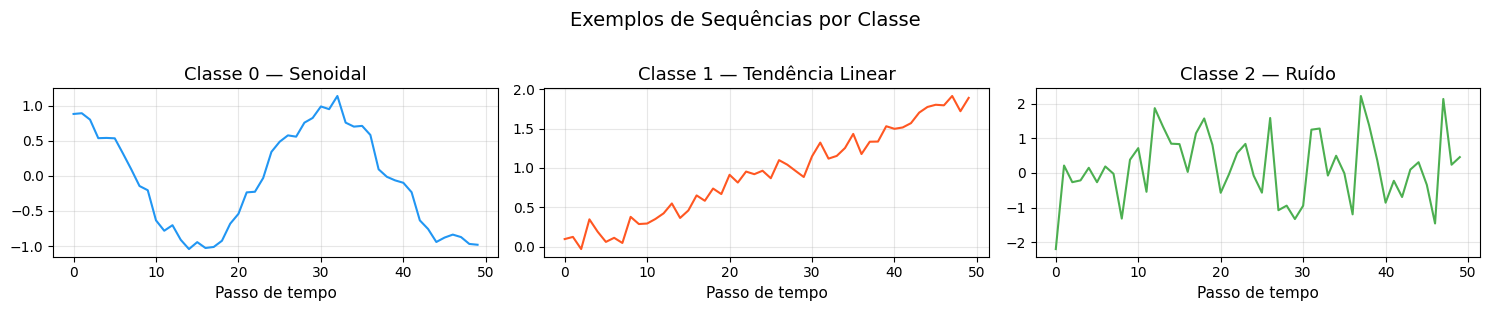

In [10]:
# Visualiza um exemplo de cada classe
nomes_clf = ["Classe 0 — Senoidal", "Classe 1 — Tendência Linear", "Classe 2 — Ruído"]
cores_clf = ["#2196F3", "#FF5722", "#4CAF50"]

fig, axes = plt.subplots(1, 3, figsize=(15, 3))
for k, (ax, nome, cor) in enumerate(zip(axes, nomes_clf, cores_clf)):
    exemplo = X_clf[y_clf == k][0]
    ax.plot(exemplo, color=cor, lw=1.5)
    ax.set_title(nome, fontsize=13)
    ax.set_xlabel("Passo de tempo", fontsize=11)
    ax.grid(alpha=0.3)

plt.suptitle("Exemplos de Sequências por Classe", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 5.3 Preparação dos Dados

In [11]:
# Normalização
scaler_clf = StandardScaler()
X_clf_norm = scaler_clf.fit_transform(X_clf)

# Divisão treino/teste 80/20
n_tr = int(0.8 * len(X_clf_norm))
X_tr_c, X_te_c = X_clf_norm[:n_tr], X_clf_norm[n_tr:]
y_tr_c, y_te_c = y_clf[:n_tr],      y_clf[n_tr:]

# Tensores — RNN espera (batch, seq_len, features)
X_tr_ct = torch.tensor(X_tr_c, dtype=torch.float32).unsqueeze(-1).to(device)
y_tr_ct = torch.tensor(y_tr_c, dtype=torch.long).to(device)
X_te_ct = torch.tensor(X_te_c, dtype=torch.float32).unsqueeze(-1).to(device)
y_te_ct = torch.tensor(y_te_c, dtype=torch.long).to(device)

loader_tr_c = DataLoader(TensorDataset(X_tr_ct, y_tr_ct), batch_size=64, shuffle=True)

print(f"Shape X_tr_ct: {X_tr_ct.shape}  →  (amostras, seq_len, features)")
print(f"Treino: {len(X_tr_c)} | Teste: {len(X_te_c)}")

Shape X_tr_ct: torch.Size([1200, 50, 1])  →  (amostras, seq_len, features)
Treino: 1200 | Teste: 300


### 5.4 Modelo RNN para Classificação

A estrutura é idêntica à de regressão, exceto pela camada de saída:
- **Regressão**: `nn.Linear(hidden, 1)` — valor contínuo
- **Classificação**: `nn.Linear(hidden, n_classes)` — logits por classe

Usamos `CrossEntropyLoss` (softmax embutido) e a saída é linear — exatamente como na Aula 03 e na Aula 05.

In [12]:
class ClassificacaoRNN(nn.Module):
    """RNN simples para classificação de sequências (many-to-one)."""

    def __init__(self, input_size=1, hidden_size=64, num_layers=2,
                 n_classes=3, dropout=0.2):
        super().__init__()
        self.rnn = nn.RNN(
            input_size,
            hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout,
            nonlinearity='tanh',
        )
        self.fc = nn.Linear(hidden_size, n_classes)   # logits — sem softmax

    def forward(self, x):
        output, _ = self.rnn(x)
        return self.fc(output[:, -1])   # último passo de tempo


modelo_clf = ClassificacaoRNN().to(device)
print(modelo_clf)
n_params_c = sum(p.numel() for p in modelo_clf.parameters() if p.requires_grad)
print(f"\nParâmetros treináveis: {n_params_c:,}")

ClassificacaoRNN(
  (rnn): RNN(1, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=3, bias=True)
)

Parâmetros treináveis: 12,803


### 5.5 Treinamento

In [13]:
criterio_clf   = nn.CrossEntropyLoss()
otimizador_clf = optim.Adam(modelo_clf.parameters(), lr=0.001)
epocas_clf     = 50

hist_loss_tr_c, hist_loss_te_c = [], []
hist_acc_tr_c,  hist_acc_te_c  = [], []

for epoca in range(1, epocas_clf + 1):

    modelo_clf.train()
    loss_tr, acc_tr, n_batches = 0.0, 0.0, 0
    for xb, yb in loader_tr_c:
        otimizador_clf.zero_grad()
        logits = modelo_clf(xb)
        loss   = criterio_clf(logits, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(modelo_clf.parameters(), max_norm=1.0)
        otimizador_clf.step()
        loss_tr += loss.item()
        acc_tr  += (logits.argmax(1) == yb).float().mean().item()
        n_batches += 1
    loss_tr /= n_batches
    acc_tr  /= n_batches

    modelo_clf.eval()
    with torch.no_grad():
        logits_te = modelo_clf(X_te_ct)
        loss_te   = criterio_clf(logits_te, y_te_ct).item()
        acc_te    = (logits_te.argmax(1) == y_te_ct).float().mean().item()

    hist_loss_tr_c.append(loss_tr);  hist_loss_te_c.append(loss_te)
    hist_acc_tr_c.append(acc_tr);    hist_acc_te_c.append(acc_te)

    if epoca % 10 == 0 or epoca == 1:
        print(f"Época {epoca:>3} | Loss: {loss_tr:.4f} "
              f"| Acc Treino: {acc_tr:.3f} | Acc Teste: {acc_te:.3f}")

print(f"\nAcurácia final no teste: {hist_acc_te_c[-1]*100:.2f}%")

Época   1 | Loss: 1.1025 | Acc Treino: 0.344 | Acc Teste: 0.340
Época  10 | Loss: 0.4881 | Acc Treino: 0.700 | Acc Teste: 0.593
Época  20 | Loss: 0.1986 | Acc Treino: 0.950 | Acc Teste: 0.963
Época  30 | Loss: 0.0929 | Acc Treino: 0.979 | Acc Teste: 0.947
Época  40 | Loss: 0.0364 | Acc Treino: 0.992 | Acc Teste: 0.990
Época  50 | Loss: 0.0900 | Acc Treino: 0.971 | Acc Teste: 0.977

Acurácia final no teste: 97.67%


### 5.6 Resultados

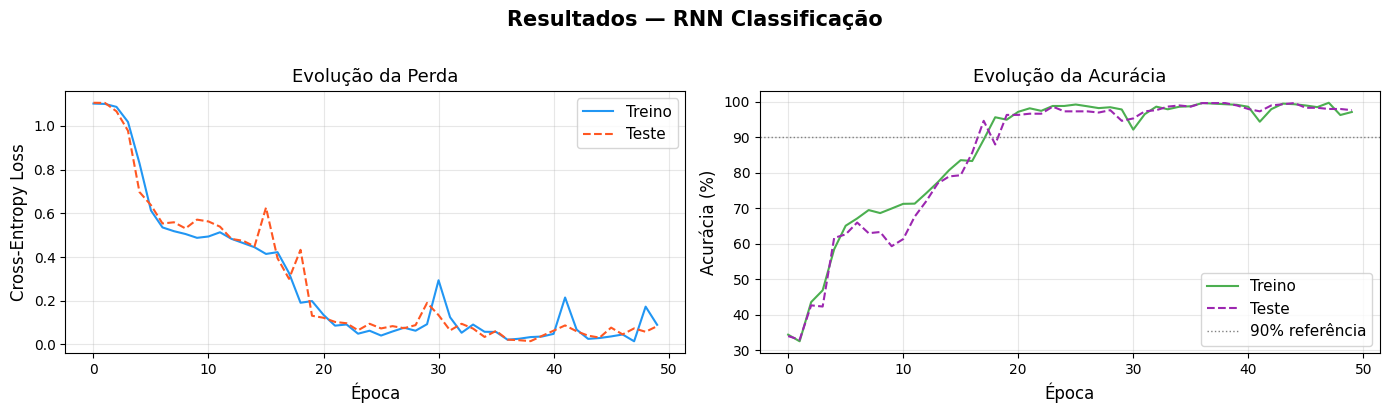

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.plot(hist_loss_tr_c, label="Treino", color="#2196F3", lw=1.5)
ax.plot(hist_loss_te_c, label="Teste",  color="#FF5722", lw=1.5, linestyle="--")
ax.set_xlabel("Época", fontsize=12)
ax.set_ylabel("Cross-Entropy Loss", fontsize=12)
ax.set_title("Evolução da Perda", fontsize=13)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

ax = axes[1]
ax.plot([a * 100 for a in hist_acc_tr_c], label="Treino", color="#4CAF50", lw=1.5)
ax.plot([a * 100 for a in hist_acc_te_c], label="Teste",  color="#9C27B0", lw=1.5, linestyle="--")
ax.axhline(90, color="gray", lw=1, linestyle=":", label="90% referência")
ax.set_xlabel("Época", fontsize=12)
ax.set_ylabel("Acurácia (%)", fontsize=12)
ax.set_title("Evolução da Acurácia", fontsize=13)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.suptitle("Resultados — RNN Classificação", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

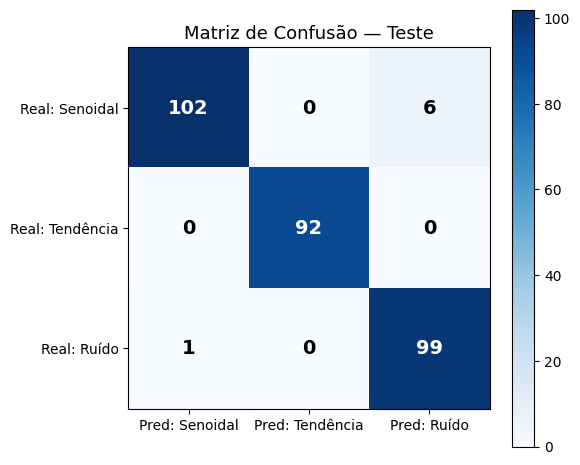

In [15]:
# Matriz de confusão
modelo_clf.eval()
with torch.no_grad():
    pred_te = modelo_clf(X_te_ct).argmax(1).cpu().numpy()

matriz = np.zeros((3, 3), dtype=int)
np.add.at(matriz, (y_te_c, pred_te), 1)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(matriz, cmap="Blues")
plt.colorbar(im, ax=ax)
for i in range(3):
    for j in range(3):
        cor = "white" if matriz[i, j] > matriz.max() * 0.6 else "black"
        ax.text(j, i, str(matriz[i, j]), ha="center", va="center",
                fontsize=14, color=cor, fontweight="bold")
ax.set_xticks(range(3))
ax.set_yticks(range(3))
rotulos = ["Senoidal", "Tendência", "Ruído"]
ax.set_xticklabels([f"Pred: {r}" for r in rotulos], fontsize=10)
ax.set_yticklabels([f"Real: {r}" for r in rotulos], fontsize=10)
ax.set_title("Matriz de Confusão — Teste", fontsize=13)
plt.tight_layout()
plt.show()

---

## 6. Comparativo e Próximos Passos

### 6.1 FNN vs RNN

| Aspecto | FNN (Aula 03) | RNN (Aula 04) |
|---------|--------------|---------------|
| **Entrada** | Vetor fixo $(batch, features)$ | Sequência $(batch, seq\_len, features)$ |
| **Memória** | Nenhuma | $h_t$ persiste entre passos |
| **Parâmetros** | Crescem com features | Crescem com `hidden_size` |
| **Dados temporais** | Trata passos como independentes | Captura dependências temporais |
| **Saída** | Vetor único | Vetor por passo ou apenas o último |

### 6.2 Many-to-One vs Many-to-Many

Nesta aula usamos a arquitetura **many-to-one**: a RNN processa toda a sequência e gera uma única saída no último passo. Existem outras configurações:

| Configuração | Uso | Como implementar |
|-------------|-----|------------------|
| **Many-to-one** | Classificação, previsão de um passo | `output[:, -1, :]` |
| **Many-to-many** | Tradução, geração de sequências | `output` completo |
| **One-to-many** | Legenda de imagem, síntese | Entrada repetida a cada passo |

### 6.3 A Limitação Fundamental da RNN Simples

A RNN simples funciona bem em sequências curtas. Para sequências longas, o problema do gradiente que desvanece impede o aprendizado de dependências distantes. Compare o RMSE obtido aqui com o da **Aula 05 (LSTM)** — você verá que a LSTM performa melhor exatamente porque resolve esse problema.

In [16]:
print("=" * 58)
print(" RESUMO — Aula 04: RNN com PyTorch")
print("=" * 58)
print()
print(" CASO 1 — REGRESSÃO (previsão de série temporal)")
print(f"   Arquitetura : RNN(hidden=64, layers=2) -> Linear(1)")
print(f"   Seq. length : {SEQ_LEN} passos")
print(f"   RMSE final  : {rmse:.4f} (escala original)")
print()
print(" CASO 2 — CLASSIFICAÇÃO (tipo de sequência)")
print(f"   Arquitetura : RNN(hidden=64, layers=2) -> Linear(3)")
print(f"   Seq. length : {SEQ_LEN_CLF} passos")
print(f"   Acurácia    : {hist_acc_te_c[-1]*100:.2f}%")
print()
print("=" * 58)

 RESUMO — Aula 04: RNN com PyTorch

 CASO 1 — REGRESSÃO (previsão de série temporal)
   Arquitetura : RNN(hidden=64, layers=2) -> Linear(1)
   Seq. length : 30 passos
   RMSE final  : 10.7750 (escala original)

 CASO 2 — CLASSIFICAÇÃO (tipo de sequência)
   Arquitetura : RNN(hidden=64, layers=2) -> Linear(3)
   Seq. length : 50 passos
   Acurácia    : 97.67%

